In [ ]:
# @title **Step 1: Install and Import Dependencies**
# @markdown Run this cell to install/import required packages

import os
import sys
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
def set_seeds(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(42)

print("✅ All imports completed successfully!")
print(f"Random seed set to: 42")

✅ All imports completed successfully!
Random seed set to: 42


In [ ]:
# @title **Step 2: Check GPU Configuration**
# @markdown This cell verifies GPU setup and sets device

import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.transforms import functional as TF
from google.colab import files

# Auto-detect device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("🚀 GPU/DEVICE CONFIGURATION")
print("=" * 60)
print(f"PyTorch Device: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"🔹 GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"🔹 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"🔹 CUDA Version: {torch.version.cuda}")
else:
    print("⚠️ WARNING: Running on CPU - Training will be VERY slow!")
    print("💡 Solution: Go to Runtime → Change runtime type → Select GPU")
print("=" * 60)

🚀 GPU/DEVICE CONFIGURATION
PyTorch Device: cuda
🔹 GPU Name: Tesla T4
🔹 GPU Memory: 15.83 GB
🔹 CUDA Version: 12.6


In [ ]:
# @title **Step 3: Upload Dataset Files**
# @markdown Upload your image and mask zip files
# @markdown **Instructions:**
# @markdown 1. Prepare two zip files:
# @markdown    - `flowers.zip`: Contains RGB images (.jpg/.png)
# @markdown    - `masks_semantic.zip`: Contains binary masks (.png)
# @markdown 2. Ensure matching filenames (e.g., flower1.jpg ↔ flower1.png)
# @markdown 3. Click the upload buttons when prompted

from google.colab import files
import zipfile
import time

# Define folder paths
IMG_DEST = "/content/dataset"
MASK_DEST = "/content/masks"

# Clean previous runs
for d in [IMG_DEST, MASK_DEST]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)

print("📁 Folder structure created:")
print(f"   Images will be saved to: {IMG_DEST}")
print(f"   Masks will be saved to: {MASK_DEST}")
print()

# Upload images
print("⬇️" * 30)
print("STEP 1: Upload ORIGINAL IMAGES Zip file (e.g., flowers.zip)")
print("⬇️" * 30)
uploaded_img = files.upload()
img_zip = list(uploaded_img.keys())[0]
print(f"✅ Uploaded: {img_zip} ({os.path.getsize(img_zip)/1024/1024:.2f} MB)")

# Upload masks
print("\n" + "⬇️" * 30)
print("STEP 2: Upload MASKS Zip file (e.g., masks_semantic.zip)")
print("⬇️" * 30)
uploaded_mask = files.upload()
mask_zip = list(uploaded_mask.keys())[0]
print(f"✅ Uploaded: {mask_zip} ({os.path.getsize(mask_zip)/1024/1024:.2f} MB)")

print("\n⏳ Extracting files...")
# Extract images
with zipfile.ZipFile(img_zip, 'r') as zip_ref:
    zip_ref.extractall(IMG_DEST)

# Extract masks
with zipfile.ZipFile(mask_zip, 'r') as zip_ref:
    zip_ref.extractall(MASK_DEST)

print("✅ Extraction complete!")
print(f"📊 Image folder: {len(os.listdir(IMG_DEST))} items")
print(f"📊 Mask folder: {len(os.listdir(MASK_DEST))} items")

📁 Folder structure created:
   Images will be saved to: /content/dataset
   Masks will be saved to: /content/masks

⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️
STEP 1: Upload ORIGINAL IMAGES Zip file (e.g., flowers.zip)
⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️


Saving archive (5).zip to archive (5) (1).zip
✅ Uploaded: archive (5) (1).zip (184.38 MB)

⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️
STEP 2: Upload MASKS Zip file (e.g., masks_semantic.zip)
⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️⬇️


Saving final_bw_masks.zip to final_bw_masks (1).zip
✅ Uploaded: final_bw_masks (1).zip (7.50 MB)

⏳ Extracting files...
✅ Extraction complete!
📊 Image folder: 8 items
📊 Mask folder: 7397 items


In [ ]:
# @title **Step 4: Data Inspection & Pair Matching**
# @markdown This cell checks your data and creates image-mask pairs

def match_pairs(img_folder, mask_folder):
    """Match image files with corresponding mask files"""
    valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

    # Get all image files
    img_paths = []
    for ext in valid_exts:
        img_paths.extend(list(Path(img_folder).rglob(f"*{ext}")))
        img_paths.extend(list(Path(img_folder).rglob(f"*{ext.upper()}")))

    img_paths = sorted(img_paths)
    print(f"🔍 Found {len(img_paths)} image files")

    # Match with masks
    pairs = []
    unmatched = []

    for img_p in tqdm(img_paths, desc="Matching files"):
        stem = img_p.stem
        # Try to find matching mask
        mask_found = False
        for ext in valid_exts:
            mask_path = Path(mask_folder) / f"{stem}{ext}"
            if mask_path.exists():
                pairs.append((str(img_p), str(mask_path)))
                mask_found = True
                break
            # Also check uppercase extension
            mask_path = Path(mask_folder) / f"{stem}{ext.upper()}"
            if mask_path.exists():
                pairs.append((str(img_p), str(mask_path)))
                mask_found = True
                break

        if not mask_found:
            unmatched.append(str(img_p))

    return pairs, unmatched

# Match pairs
pairs, unmatched = match_pairs(IMG_DEST, MASK_DEST)

print("\n" + "=" * 60)
print("📊 DATA SUMMARY")
print("=" * 60)
print(f"✅ Successfully matched: {len(pairs)} pairs")
print(f"⚠️  Unmatched images: {len(unmatched)}")

if len(unmatched) > 0:
    print("\n❌ Unmatched files (check filenames):")
    for f in unmatched[:5]:  # Show first 5
        print(f"   - {Path(f).name}")
    if len(unmatched) > 5:
        print(f"   ... and {len(unmatched)-5} more")

if len(pairs) == 0:
    raise ValueError("❌ CRITICAL ERROR: No image-mask pairs found!")
    print("💡 Check that:")
    print("   1. Filenames match (e.g., 'image1.jpg' ↔ 'image1.png')")
    print("   2. Files are in correct folders")
    print("   3. File extensions are supported (.jpg, .png, etc.)")

# Display sample pair
if len(pairs) > 0:
    print("\n🔍 Sample matched pair:")
    img_path, mask_path = pairs[0]
    print(f"   Image: {Path(img_path).name}")
    print(f"   Mask: {Path(mask_path).name}")

    # Show sample image and mask
    try:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        axes[0].imshow(img)
        axes[0].set_title(f"Image: {Path(img_path).name}")
        axes[0].axis('off')

        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title(f"Mask: {Path(mask_path).name}")
        axes[1].axis('off')

        plt.suptitle("Sample Image-Mask Pair", fontsize=14)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠️ Could not display sample: {e}")

In [ ]:
# @title **Step 5: Create Train/Validation Splits**
# @markdown This cell splits data into training (80%) and validation (20%) sets

# Shuffle pairs with fixed seed for reproducibility
random.shuffle(pairs)

# Split ratio
TRAIN_RATIO = 0.8
split_idx = int(len(pairs) * TRAIN_RATIO)

train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]

print("📊 DATA SPLIT SUMMARY")
print("=" * 60)
print(f"Total pairs: {len(pairs)}")
print(f"Training set: {len(train_pairs)} pairs ({len(train_pairs)/len(pairs)*100:.1f}%)")
print(f"Validation set: {len(val_pairs)} pairs ({len(val_pairs)/len(pairs)*100:.1f}%)")

if len(train_pairs) < 10:
    print("⚠️ WARNING: Training set very small (<10 images)!")
    print("   Model may not learn effectively.")

if len(val_pairs) < 5:
    print("⚠️ WARNING: Validation set very small (<5 images)!")
    print("   Validation metrics may not be reliable.")

📊 DATA SPLIT SUMMARY
Total pairs: 7397
Training set: 5917 pairs (80.0%)
Validation set: 1480 pairs (20.0%)


✅ Datasets created successfully!
Training samples: 5917
Validation samples: 1480

🔍 Visualizing a training sample:


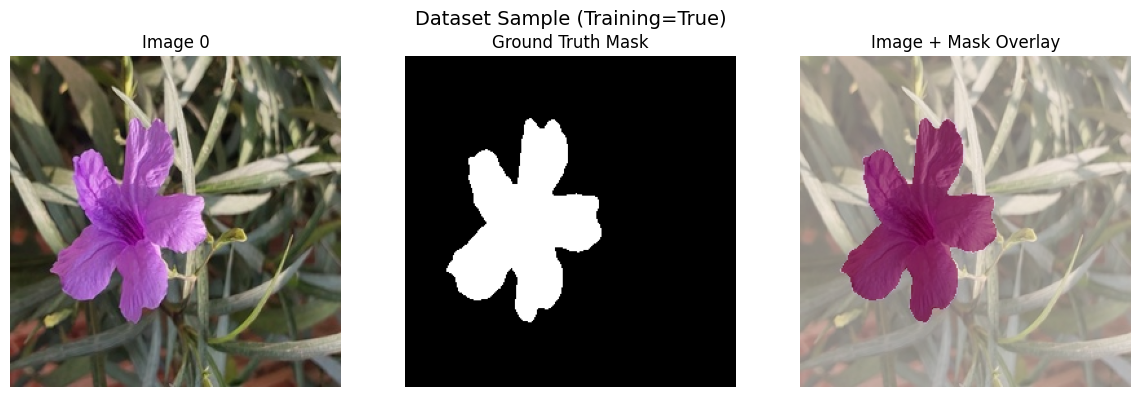

In [ ]:
# @title **Step 6: Define Dataset Class**
# @markdown This cell defines the PyTorch Dataset class for loading images and masks

class FlowerDataset(Dataset):
    """PyTorch Dataset for flower segmentation"""

    def __init__(self, pairs, image_size=256, train=True):
        """
        Args:
            pairs: List of (image_path, mask_path) tuples
            image_size: Size to resize images to (square)
            train: If True, apply data augmentation
        """
        self.pairs = pairs
        self.image_size = image_size
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        # Get paths
        img_path, mask_path = self.pairs[idx]

        # Load image and mask
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Resize
        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        # Data augmentation (only during training)
        if self.train and random.random() > 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        # Convert to tensors
        img_tensor = TF.to_tensor(img)  # Shape: [3, H, W]
        mask_tensor = TF.to_tensor(mask)  # Shape: [1, H, W]

        # Convert mask to binary (0 or 1)
        mask_tensor = (mask_tensor > 0.5).float()

        return img_tensor, mask_tensor

    def visualize_sample(self, idx=0):
        """Visualize a sample from the dataset"""
        img, mask = self.__getitem__(idx)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        # Show original image
        axes[0].imshow(img.permute(1, 2, 0))
        axes[0].set_title(f"Image {idx}")
        axes[0].axis('off')

        # Show mask
        axes[1].imshow(mask.squeeze(), cmap='gray')
        axes[1].set_title("Ground Truth Mask")
        axes[1].axis('off')

        # Show overlay
        axes[2].imshow(img.permute(1, 2, 0))
        axes[2].imshow(mask.squeeze(), cmap='Reds', alpha=0.5)
        axes[2].set_title("Image + Mask Overlay")
        axes[2].axis('off')

        plt.suptitle(f"Dataset Sample (Training={self.train})", fontsize=14)
        plt.tight_layout()
        plt.show()

# Create dataset instances
train_dataset = FlowerDataset(train_pairs, image_size=256, train=True)
val_dataset = FlowerDataset(val_pairs, image_size=256, train=False)

print("✅ Datasets created successfully!")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Visualize a sample
print("\n🔍 Visualizing a training sample:")
train_dataset.visualize_sample(0)

In [ ]:
# @title **Step 7: Define Evaluation Metrics**
# @markdown This cell defines metrics for model evaluation

def calculate_metrics(pred, target, threshold=0.5):
    """
    Calculate Dice coefficient and IoU for binary segmentation

    Args:
        pred: Model predictions (logits) shape: [B, 1, H, W]
        target: Ground truth masks shape: [B, 1, H, W]
        threshold: Threshold for binary conversion

    Returns:
        dice: Dice coefficient (F1 score)
        iou: Intersection over Union
    """
    # Convert logits to probabilities and then to binary
    pred_prob = torch.sigmoid(pred)
    pred_binary = (pred_prob > threshold).float()

    # Flatten tensors
    pred_flat = pred_binary.view(-1)
    target_flat = target.view(-1).float()

    # Calculate intersection and union
    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum()

    # Dice coefficient (F1 score)
    dice = (2. * intersection) / (union + 1e-6)

    # IoU (Jaccard Index)
    iou = intersection / (union - intersection + 1e-6)

    return dice.item(), iou.item()

# Test the metrics function
print("✅ Metrics function defined")
print("   - Dice Coefficient (F1 Score)")
print("   - Intersection over Union (IoU)")

✅ Metrics function defined
   - Dice Coefficient (F1 Score)
   - Intersection over Union (IoU)


In [ ]:
# @title **Step 8: Define Baseline U-Net Model**
# @markdown This cell defines the U-Net architecture with ResNet18 encoder

import torch.nn as nn

class SimpleUNet(nn.Module):
    """Baseline U-Net for binary segmentation with ResNet18 encoder"""

    def __init__(self):
        super().__init__()

        # ===== ENCODER (ResNet18) =====
        resnet = models.resnet18(weights='DEFAULT')

        # Extract encoder layers
        self.enc1 = nn.Sequential(*list(resnet.children())[:3])   # [B, 64, 128, 128]
        self.enc2 = nn.Sequential(*list(resnet.children())[3:5])  # [B, 64, 64, 64]
        self.enc3 = resnet.layer1                                 # [B, 64, 64, 64]
        self.enc4 = resnet.layer2                                 # [B, 128, 32, 32]
        self.enc5 = resnet.layer3                                 # [B, 256, 16, 16]
        self.enc6 = resnet.layer4                                 # [B, 512, 8, 8]

        # ===== DECODER =====
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)  # 8→16
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)  # 16→32
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)   # 32→64
        self.up4 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)    # 64→128
        self.up5 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)    # 128→256
        self.final = nn.Conv2d(64, 1, kernel_size=1)                      # Output

        # Initialize decoder weights
        self._init_weights()

    def _init_weights(self):
        """Initialize decoder weights"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Encoder forward pass
        x1 = self.enc1(x)   # [B, 64, 128, 128]
        x2 = self.enc2(x1)  # [B, 64, 64, 64]
        x3 = self.enc3(x2)  # [B, 64, 64, 64]
        x4 = self.enc4(x3)  # [B, 128, 32, 32]
        x5 = self.enc5(x4)  # [B, 256, 16, 16]
        x6 = self.enc6(x5)  # [B, 512, 8, 8]

        # Decoder with skip connections
        x = self.up1(x6)    # [B, 256, 16, 16]
        x = x + x5          # Skip connection

        x = self.up2(x)     # [B, 128, 32, 32]
        x = x + x4          # Skip connection

        x = self.up3(x)     # [B, 64, 64, 64]
        x = x + x3          # Skip connection

        x = self.up4(x)     # [B, 64, 128, 128]
        x = x + x1          # Skip connection

        x = self.up5(x)     # [B, 64, 256, 256]
        x = self.final(x)   # [B, 1, 256, 256]

        return x

# Create model instance
model = SimpleUNet().to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✅ Model created successfully!")
print("=" * 60)
print("📊 MODEL ARCHITECTURE SUMMARY")
print("=" * 60)
print(f"Model: U-Net with ResNet18 encoder")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {next(model.parameters()).device}")
print("=" * 60)

# Test forward pass
if len(train_pairs) > 0:
    test_batch = torch.randn(2, 3, 256, 256).to(DEVICE)
    with torch.no_grad():
        output = model(test_batch)
    print(f"\n🔍 Forward pass test:")
    print(f"   Input shape: {test_batch.shape}")
    print(f"   Output shape: {output.shape}")
    print("✅ Model forward pass working correctly!")

✅ Model created successfully!
📊 MODEL ARCHITECTURE SUMMARY
Model: U-Net with ResNet18 encoder
Total parameters: 11,898,049
Trainable parameters: 11,898,049
Device: cuda:0

🔍 Forward pass test:
   Input shape: torch.Size([2, 3, 256, 256])
   Output shape: torch.Size([2, 1, 256, 256])
✅ Model forward pass working correctly!


In [ ]:
# @title **Step 9: Configure Training Parameters**
# @markdown Adjust training hyperparameters here

# Hyperparameters
BATCH_SIZE = 8          # @param {type:"integer"}
LEARNING_RATE = 1e-4    # @param {type:"number"}
EPOCHS = 50            # @param {type:"integer"}
IMAGE_SIZE = 256        # @param {type:"integer"}

print("🎯 TRAINING CONFIGURATION")
print("=" * 60)
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Epochs: {EPOCHS}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Training samples: {len(train_pairs)}")
print(f"Validation samples: {len(val_pairs)}")
print(f"Device: {DEVICE}")
print("=" * 60)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if DEVICE.type == "cuda" else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if DEVICE.type == "cuda" else False
)

print(f"\n✅ Data loaders created:")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()  # Binary Cross Entropy with logits
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"\n✅ Loss function: {criterion.__class__.__name__}")
print(f"✅ Optimizer: Adam (lr={LEARNING_RATE})")

🎯 TRAINING CONFIGURATION
Batch size: 8
Learning rate: 0.0001
Epochs: 50
Image size: 256x256
Training samples: 5917
Validation samples: 1480
Device: cuda

✅ Data loaders created:
   Training batches: 740
   Validation batches: 185

✅ Loss function: BCEWithLogitsLoss
✅ Optimizer: Adam (lr=0.0001)


In [ ]:
# @title **Fixed DataLoader Setup**
# @markdown Use this code to avoid multiprocessing errors

# In Colab, it's safer to use num_workers=0 or handle it properly
import torch
import os

# Check if we're in Colab
IN_COLAB = 'COLAB_GPU' in os.environ

# Create DataLoaders with proper settings for Colab
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0 if IN_COLAB else 2,  # Use 0 in Colab to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0 if IN_COLAB else 2,  # Use 0 in Colab
    pin_memory=True if torch.cuda.is_available() else False
)

In [ ]:
# @title **Step 10: Start Training**
# @markdown **Run this cell to begin training** (This will take 25-40 minutes on GPU)

import time
from datetime import datetime

# Training history storage
history = {
    'train_loss': [], 'val_loss': [],
    'train_dice': [], 'val_dice': [],
    'train_iou': [], 'val_iou': []
}

print("🚀 STARTING TRAINING")
print("=" * 60)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Epochs: {EPOCHS}")
print("=" * 60)

# Track best model
best_val_dice = 0.0
best_model_state = None

# Manual cleanup function
def cleanup_dataloaders():
    """Properly cleanup dataloaders to avoid multiprocessing errors"""
    global train_loader, val_loader
    if 'train_loader' in globals():
        train_loader._iterator = None
    if 'val_loader' in globals():
        val_loader._iterator = None
    import gc
    gc.collect()

try:
    # Training loop
    for epoch in range(EPOCHS):
        epoch_start_time = time.time()

        # ===== TRAINING PHASE =====
        model.train()
        train_loss = 0.0
        train_dice = 0.0
        train_iou = 0.0

        # Create fresh DataLoader each epoch (avoids multiprocessing issues)
        train_loader_single = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=0,  # Critical: use 0 workers in Colab
            pin_memory=True if DEVICE.type == "cuda" else False
        )

        train_pbar = tqdm(train_loader_single, desc=f"Epoch {epoch+1:03d}/{EPOCHS} [Train]",
                         leave=False, bar_format='{l_bar}{bar:20}{r_bar}{bar:-20b}')

        for images, masks in train_pbar:
            # Move to device
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Calculate metrics
            dice, iou = calculate_metrics(outputs, masks)

            # Accumulate
            train_loss += loss.item()
            train_dice += dice
            train_iou += iou

            # Update progress bar
            train_pbar.set_postfix({
                'Loss': f"{loss.item():.4f}",
                'Dice': f"{dice:.4f}",
                'IoU': f"{iou:.4f}"
            })

        # Cleanup training loader
        del train_loader_single
        train_loader_single = None

        # Average training metrics
        train_loss /= len(train_loader)
        train_dice /= len(train_loader)
        train_iou /= len(train_loader)

        history['train_loss'].append(train_loss)
        history['train_dice'].append(train_dice)
        history['train_iou'].append(train_iou)

        # ===== VALIDATION PHASE =====
        model.eval()
        val_loss = 0.0
        val_dice = 0.0
        val_iou = 0.0

        # Create fresh validation DataLoader
        val_loader_single = DataLoader(
            val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,  # Critical: use 0 workers in Colab
            pin_memory=True if DEVICE.type == "cuda" else False
        )

        val_pbar = tqdm(val_loader_single, desc=f"Epoch {epoch+1:03d}/{EPOCHS} [Val]",
                       leave=False, bar_format='{l_bar}{bar:20}{r_bar}{bar:-20b}')

        with torch.no_grad():
            for images, masks in val_pbar:
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)

                outputs = model(images)
                loss = criterion(outputs, masks)

                dice, iou = calculate_metrics(outputs, masks)

                val_loss += loss.item()
                val_dice += dice
                val_iou += iou

                val_pbar.set_postfix({
                    'Loss': f"{loss.item():.4f}",
                    'Dice': f"{dice:.4f}",
                    'IoU': f"{iou:.4f}"
                })

        # Cleanup validation loader
        del val_loader_single
        val_loader_single = None

        # Average validation metrics
        val_loss /= len(val_loader)
        val_dice /= len(val_loader)
        val_iou /= len(val_loader)

        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        history['val_iou'].append(val_iou)

        # Save best model
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_model_state = model.state_dict().copy()
            best_epoch = epoch + 1

        # Calculate epoch time
        epoch_time = time.time() - epoch_start_time
        remaining_time = epoch_time * (EPOCHS - epoch - 1)

        # Print epoch summary
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
              f"Time: {epoch_time:.1f}s | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f} | "
              f"Best Dice: {best_val_dice:.4f} (Epoch {best_epoch})")

except KeyboardInterrupt:
    print("\n⚠️ Training interrupted by user")
finally:
    # Always cleanup properly
    cleanup_dataloaders()

print("\n" + "=" * 60)
print("✅ TRAINING COMPLETED SUCCESSFULLY!")
print("=" * 60)
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total training time: {time.time() - start_time:.1f} seconds")
print(f"Best validation Dice: {best_val_dice:.4f} (Epoch {best_epoch})")
print("=" * 60)

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"✅ Loaded best model from epoch {best_epoch}")

🚀 STARTING TRAINING
Start time: 2025-12-18 18:59:43
Epochs: 50


Epoch 001/50 [Train]:   0%|                    | 0/740 [00:00<?, ?it/s]

Epoch 001/50 [Val]:   0%|                    | 0/185 [00:00<?, ?it/s]

Epoch 001/50 | Time: 78.0s | Train Loss: 0.3842 | Val Loss: 0.3107 | Val Dice: 0.6564 | Val IoU: 0.5050 | Best Dice: 0.6564 (Epoch 1)


Epoch 002/50 [Train]:   0%|                    | 0/740 [00:00<?, ?it/s]

...

Epoch 049/50 | Time: 79.3s | Train Loss: 0.0339 | Val Loss: 0.4997 | Val Dice: 0.7541 | Val IoU: 0.6252 | Best Dice: 0.7577 (Epoch 42)


Epoch 050/50 [Train]:   0%|                    | 0/740 [00:00<?, ?it/s]

Epoch 050/50 [Val]:   0%|                    | 0/185 [00:00<?, ?it/s]

Epoch 050/50 | Time: 79.4s | Train Loss: 0.0320 | Val Loss: 0.5476 | Val Dice: 0.7447 | Val IoU: 0.6128 | Best Dice: 0.7577 (Epoch 42)

✅ TRAINING COMPLETED SUCCESSFULLY!
End time: 2025-12-18 20:05:55


NameError: name 'start_time' is not defined

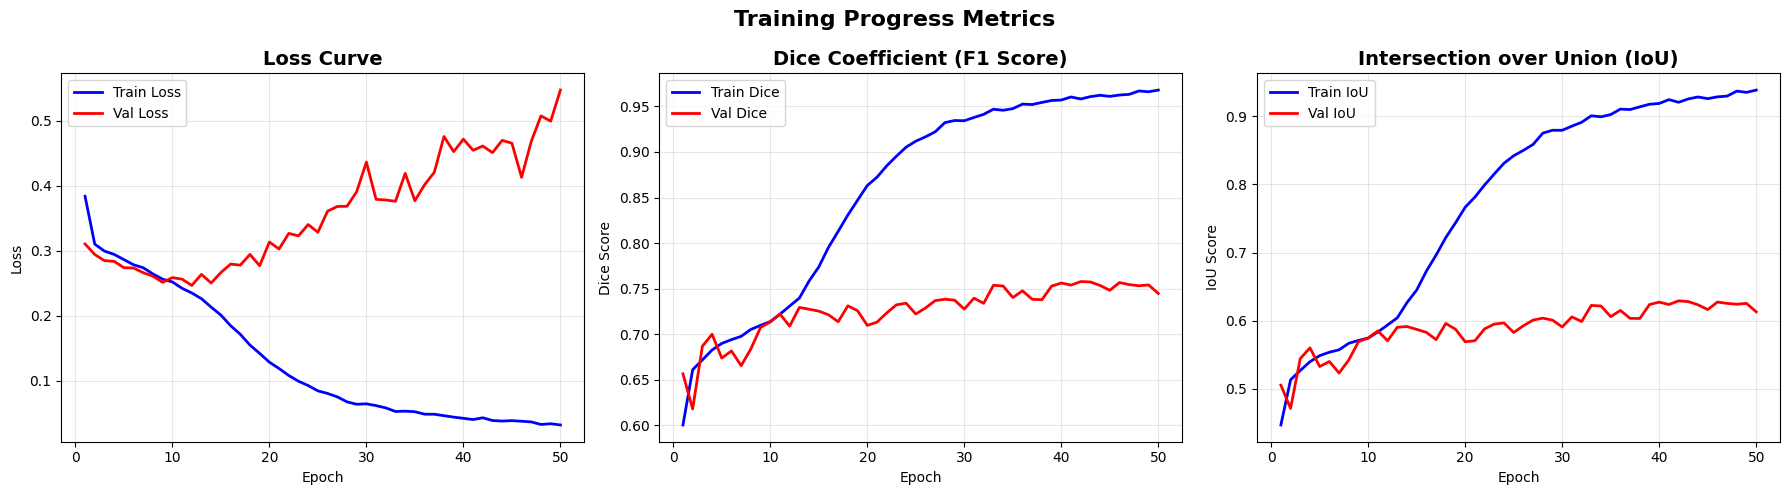


📊 FINAL MODEL PERFORMANCE
Best Validation Dice: 0.7577
Best Validation IoU: 0.6290
Final Validation Dice: 0.7447
Final Validation IoU: 0.6128


In [ ]:
# @title **Step 11: Plot Training Curves**
# @markdown Visualize training and validation metrics

def plot_training_curves(history):
    """Plot training history curves"""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Dice
    axes[1].plot(epochs, history['train_dice'], 'b-', label='Train Dice', linewidth=2)
    axes[1].plot(epochs, history['val_dice'], 'r-', label='Val Dice', linewidth=2)
    axes[1].set_title('Dice Coefficient (F1 Score)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Plot IoU
    axes[2].plot(epochs, history['train_iou'], 'b-', label='Train IoU', linewidth=2)
    axes[2].plot(epochs, history['val_iou'], 'r-', label='Val IoU', linewidth=2)
    axes[2].set_title('Intersection over Union (IoU)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('IoU Score')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('Training Progress Metrics', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print final metrics
    print("\n📊 FINAL MODEL PERFORMANCE")
    print("=" * 50)
    print(f"Best Validation Dice: {max(history['val_dice']):.4f}")
    print(f"Best Validation IoU: {max(history['val_iou']):.4f}")
    print(f"Final Validation Dice: {history['val_dice'][-1]:.4f}")
    print(f"Final Validation IoU: {history['val_iou'][-1]:.4f}")
    print("=" * 50)

# Plot curves
plot_training_curves(history)

🎨 VISUALIZING PREDICTIONS


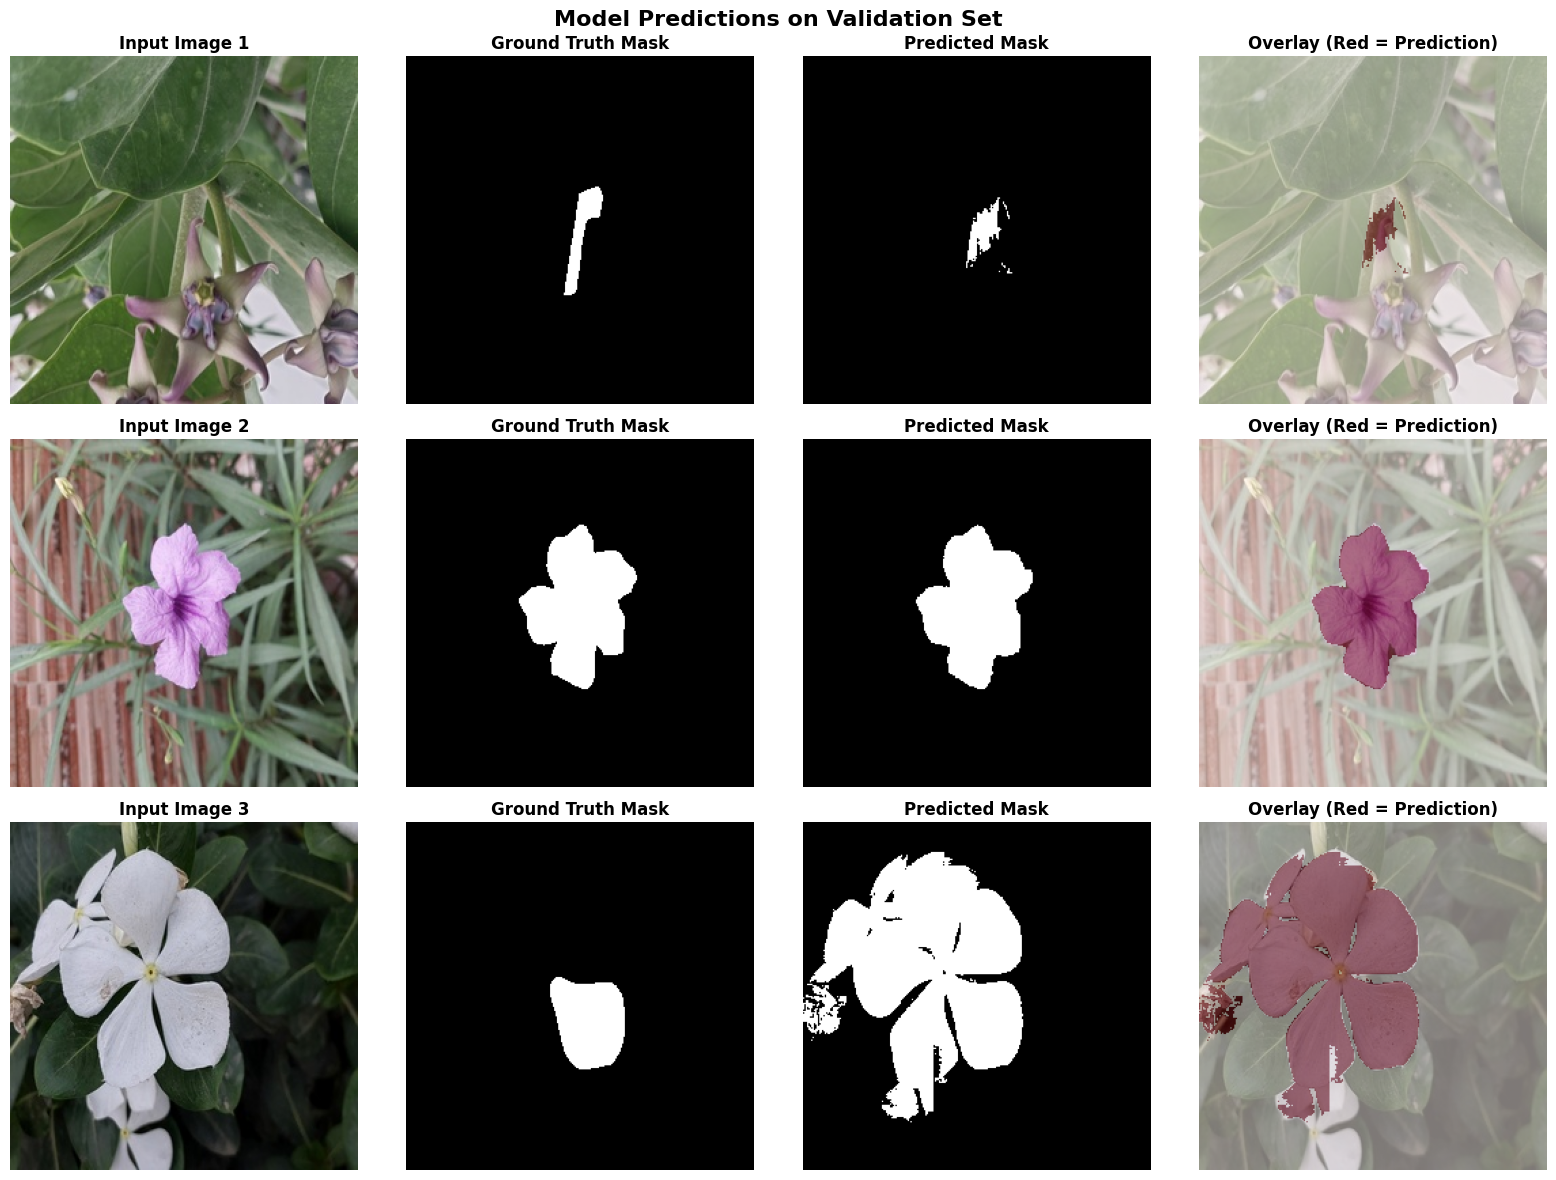


📈 Metrics for displayed samples:
Sample 1: Dice = 0.4681, IoU = 0.3056
Sample 2: Dice = 0.9839, IoU = 0.9682
Sample 3: Dice = 0.2820, IoU = 0.1641


In [ ]:
# @title **Step 12: Visualize Predictions**
# @markdown Show model predictions on validation samples

def visualize_predictions(model, dataloader, num_samples=3):
    """Visualize model predictions on sample images"""
    model.eval()

    # Get a batch of validation data
    images, masks = next(iter(dataloader))
    images = images.to(DEVICE)

    # Get predictions
    with torch.no_grad():
        preds_logits = model(images)
        preds_probs = torch.sigmoid(preds_logits)
        preds_binary = (preds_probs > 0.5).float()

    # Move to CPU for visualization
    images = images.cpu()
    masks = masks.cpu()
    preds_binary = preds_binary.cpu()

    # Plot results
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        if i >= len(images):
            break

        # Original Image
        axes[i, 0].imshow(images[i].permute(1, 2, 0))
        axes[i, 0].set_title(f"Input Image {i+1}", fontweight='bold')
        axes[i, 0].axis('off')

        # Ground Truth Mask
        axes[i, 1].imshow(masks[i].squeeze(), cmap='gray')
        axes[i, 1].set_title("Ground Truth Mask", fontweight='bold')
        axes[i, 1].axis('off')

        # Predicted Mask
        axes[i, 2].imshow(preds_binary[i].squeeze(), cmap='gray')
        axes[i, 2].set_title("Predicted Mask", fontweight='bold')
        axes[i, 2].axis('off')

        # Overlay
        axes[i, 3].imshow(images[i].permute(1, 2, 0))
        axes[i, 3].imshow(preds_binary[i].squeeze(), cmap='Reds', alpha=0.5)
        axes[i, 3].set_title("Overlay (Red = Prediction)", fontweight='bold')
        axes[i, 3].axis('off')

    plt.suptitle('Model Predictions on Validation Set', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Calculate metrics for displayed samples
    print("\n📈 Metrics for displayed samples:")
    for i in range(min(num_samples, len(images))):
        dice, iou = calculate_metrics(preds_logits[i:i+1], masks[i:i+1].to(DEVICE))
        print(f"Sample {i+1}: Dice = {dice:.4f}, IoU = {iou:.4f}")

# Visualize predictions
print("🎨 VISUALIZING PREDICTIONS")
print("=" * 60)
visualize_predictions(model, val_loader, num_samples=3)

In [ ]:
# @title **Step 13: Save Trained Model**
# @markdown Save the trained model for future use

import torch

# Save the model
model_save_path = "/content/flower_segmentation_baseline.pth"

# Prepare save dictionary
save_dict = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'best_val_dice': best_val_dice,
    'best_epoch': best_epoch,
    'hyperparameters': {
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'epochs': EPOCHS,
        'image_size': IMAGE_SIZE
    },
    'dataset_info': {
        'train_samples': len(train_pairs),
        'val_samples': len(val_pairs),
        'total_samples': len(pairs)
    }
}

# Save model
torch.save(save_dict, model_save_path)

print("💾 MODEL SAVED SUCCESSFULLY!")
print("=" * 60)
print(f"Saved to: {model_save_path}")
print(f"File size: {os.path.getsize(model_save_path) / 1024 / 1024:.2f} MB")
print("\n📦 Saved contents:")
print("   - Model weights")
print("   - Optimizer state")
print("   - Training history")
print("   - Hyperparameters")
print("   - Dataset information")
print("=" * 60)

# Download the model
print("\n⬇️ Download the trained model:")
from google.colab import files
files.download(model_save_path)

💾 MODEL SAVED SUCCESSFULLY!
Saved to: /content/flower_segmentation_baseline.pth
File size: 136.31 MB

📦 Saved contents:
   - Model weights
   - Optimizer state
   - Training history
   - Hyperparameters
   - Dataset information

⬇️ Download the trained model:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>